<a href="https://colab.research.google.com/github/Denilson-Barreto/Adote/blob/main/Sistema_de_Classifica%C3%A7%C3%A3o_Fuzzy_Complexidade_das_Atividades_Avaliativas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Instalação da biblioteca scikit-fuzzy

!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 29.1 MB/s eta 0:00:00


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Text(0, 0.5, 'Distribuição')

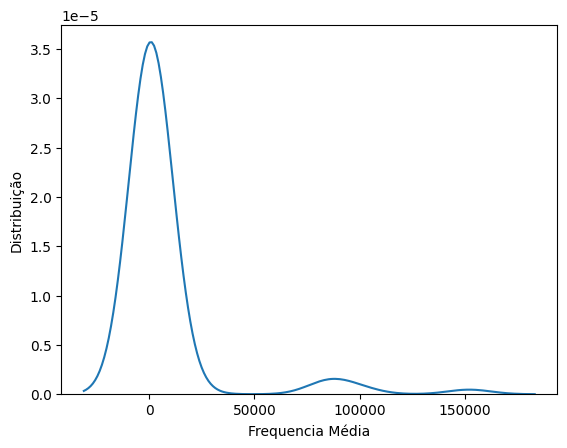

In [6]:
# Se conectando ao drive

from google.colab import drive
drive.mount('/content/drive')

# Importando as bibliotecas

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importando os dados

dados = pd.read_csv('/content/drive/MyDrive/TCC/TCC - Denilson - Funções de pertinência - Página2.csv')
dados.head()

#  Frequencia média

freq_original = dados['Intervalo'].values
sns.kdeplot(freq_original)
plt.xlabel('Frequencia Média')
plt.ylabel('Distribuição')

In [7]:
#Normalizando os dados

from sklearn.preprocessing import MinMaxScaler

dados_normalizados = pd.DataFrame(dados['Intervalo'])

def minmax_norm(df_input):
  return (dados_normalizados - dados_normalizados.min()) / (dados_normalizados.max() - dados_normalizados.min())

dm_minmax = minmax_norm(dados_normalizados)

dm_minmax.head(100)

,Intervalo
0,0.040647
1,0.658248
2,0.000395
3,0.001973
4,0.003157
...,...
78,0.000789
79,0.003157
80,0.008287
81,0.000395


In [9]:
# Criando as variaveis

nota = ctrl.Antecedent(np.array([0, 0.1, 0.2, 0.25, 0.3, 0.4, 0.5]), 'Função de pertinencia das notas')

tempo = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'Função de pertinencia do tempo ultilizado')

complexidade = ctrl.Consequent(np.arange(0, 1.1, 0.1), 'Complexibilidade')

In [10]:
# Criando as funções de pertinência

nota['Insatisfatório'] = fuzz.trapmf(nota.universe, [0,0,0.1,0.2]) #trapezoidal
nota['Regular'] = fuzz.trimf(nota.universe, [0.1,0.25,0.4]) #triangular
nota['Satisfatório'] = fuzz.trapmf(nota.universe, [0.3,0.4,0.5,0.5]) #trapezoidal

tempo['Baixo'] = fuzz.trapmf(tempo.universe,[0,0,0.3,0.4]) #trapezoidal
tempo['Medio'] = fuzz.trimf(tempo.universe, [0.3,0.5,0.7]) #triangular
tempo['Alto']=fuzz.trapmf(tempo.universe, [0.6,0.7, 1, 1]) #trapezoidal

complexidade['Baixa'] = fuzz.trimf(complexidade.universe,[0,0,0.5]) #triangular
complexidade['Media'] = fuzz.trimf(complexidade.universe, [0,0.5,1]) #triangular
complexidade['Alta'] = fuzz.trapmf(complexidade.universe, [0.6,0.8, 1, 1]) #trapezoidal

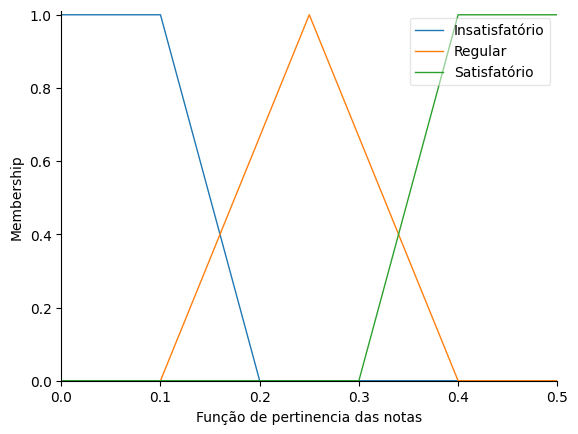

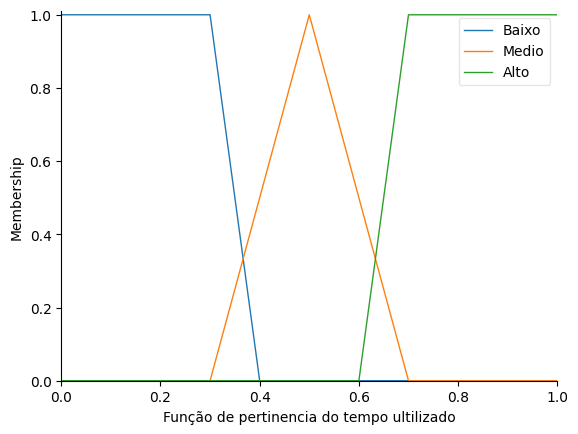

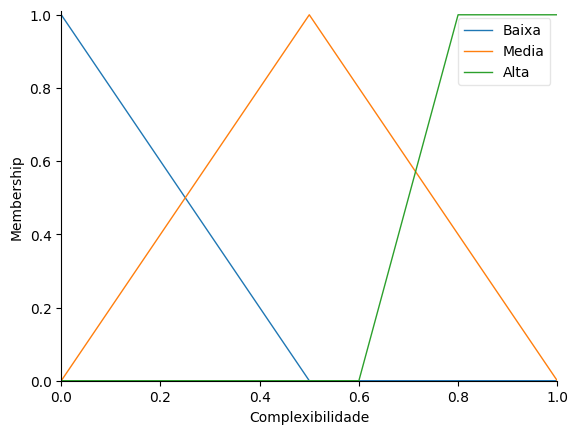

In [11]:
#Visualizando as funções de pertinências criadas

nota.view()
tempo.view()
complexidade.view()

In [12]:
# Criando as regras Fuzzy e aplicando ao simulador

regra1 = ctrl.Rule(nota['Insatisfatório'], complexidade['Alta'])
regra2 = ctrl.Rule(nota['Regular'] & tempo['Baixo'], complexidade['Baixa'])
regra3 = ctrl.Rule(nota['Regular'] & tempo['Medio'], complexidade['Alta'])
regra4 = ctrl.Rule(nota['Regular'] & tempo['Alto'], complexidade['Alta'])
regra5 = ctrl.Rule(nota['Satisfatório'] & tempo['Baixo'], complexidade['Baixa'])
regra6 = ctrl.Rule(nota['Satisfatório'] & tempo['Medio'], complexidade['Media'])
regra7 = ctrl.Rule(nota['Satisfatório'] & tempo['Alto'], complexidade['Alta'])

complexidade_ctrl = ctrl.ControlSystem([regra1, regra2, regra3, regra4,
                                        regra5, regra6, regra7])

simulador = ctrl.ControlSystemSimulation(complexidade_ctrl)

In [13]:
# Entrada de valores da Pontuação e Tempo

valor_nota = 0.5
valor_tempo = 0
simulador.input['Função de pertinencia das notas'] = valor_nota
simulador.input['Função de pertinencia do tempo ultilizado'] = valor_tempo

# Computando o resultado

simulador.compute()
simulador.output['Complexibilidade']

np.float64(0.16666666666666663)

In [14]:
# Verificação do nivel de pertinências das funções

RESULT= simulador.input['Função de pertinencia das notas'] = valor_nota
print("Pertinencia da nota INSATISFATÓRIO: \t" + str(fuzz.interp_membership(nota.universe, nota['Insatisfatório'].mf, RESULT)))
print("Pertinencia da nota REGULAR: \t" + str(fuzz.interp_membership(nota.universe, nota['Regular'].mf, RESULT)))
print("Pertinencia da nota SATISFATÓRIO: \t" + str(fuzz.interp_membership(nota.universe, nota['Satisfatório'].mf, RESULT)))

RESULT= simulador.input['Função de pertinencia do tempo ultilizado'] = valor_tempo
print("\nPertinencia do tempo BAIXO: \t" + str(fuzz.interp_membership(tempo.universe, tempo['Baixo'].mf, RESULT)))
print("Pertinencia do tempo MEDIO: \t" + str(fuzz.interp_membership(tempo.universe, tempo['Medio'].mf, RESULT)))
print("Pertinencia do tempo ALTO: \t" + str(fuzz.interp_membership(tempo.universe, tempo['Alto'].mf, RESULT)))

RESULT= simulador.output['Complexibilidade']
print("\nPertinencia da complexipilidade BAIXA: \t" + str(fuzz.interp_membership(complexidade.universe, complexidade['Baixa'].mf, RESULT)))
print("Pertinencia da complexipilidade MEDIA: \t" + str(fuzz.interp_membership(complexidade.universe, complexidade['Media'].mf, RESULT)))
print("Pertinencia da complexipilidade ALTA: \t" + str(fuzz.interp_membership(complexidade.universe, complexidade['Alta'].mf, RESULT)))


Pertinencia da nota INSATISFATÓRIO: 	0.0
Pertinencia da nota REGULAR: 	0.0
Pertinencia da nota SATISFATÓRIO: 	1.0

Pertinencia do tempo BAIXO: 	1.0
Pertinencia do tempo MEDIO: 	0.0
Pertinencia do tempo ALTO: 	0.0

Pertinencia da complexipilidade BAIXA: 	0.6666666666666667
Pertinencia da complexipilidade MEDIA: 	0.33333333333333326
Pertinencia da complexipilidade ALTA: 	0.0


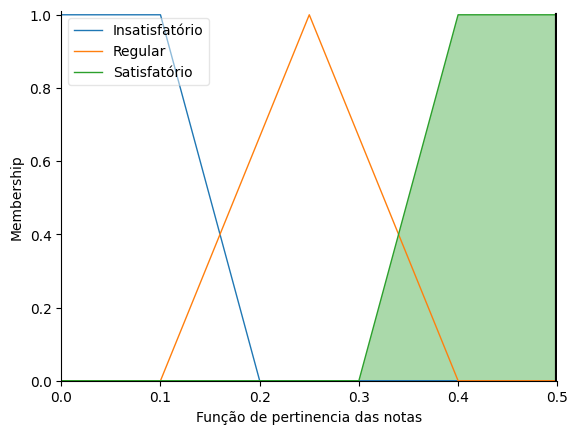

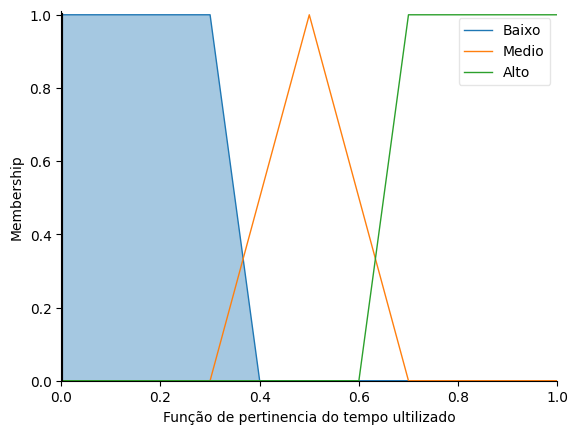

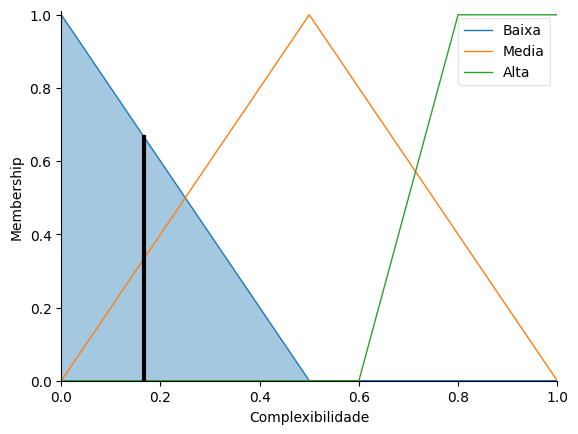

In [15]:
# Graficos da simulação

nota.view(sim=simulador)
tempo.view(sim=simulador)
complexidade.view(sim=simulador)